<a href="https://colab.research.google.com/github/Muzzamil-23/Medical_Insurance_Cost_ANN/blob/main/Medical_Insurance_Cost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Medical Insurance Cost - ANN

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf



In [ ]:
df = pd.read_csv('insurance_dataset.csv')

## Data Loading

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Data Preprocessing

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

## Encoding Categorical Features

In [ ]:
df['sex'] = df['sex'].map({
    "male": 1,
    "female": 0
})

df['smoker'] = df['smoker'].map({
    "yes": 1,
    "no": 0
})

In [ ]:
df['sex'].unique()

array([0, 1])

In [ ]:
df['smoker'].unique()

array([1, 0])

In [ ]:
df = pd.get_dummies(df, columns=['region'], dtype=int)

In [ ]:
df.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,0,1
1,18,1,33.770,1,0,1725.55230,0,0,1,0
2,28,1,33.000,3,0,4449.46200,0,0,1,0
3,33,1,22.705,0,0,21984.47061,0,1,0,0
4,32,1,28.880,0,0,3866.85520,0,1,0,0


## Defining Input Features (X) and Target Variable (y)

In [ ]:
X = df.drop('charges', axis=1)
y = df.charges

## Applying Feature Scaling

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled,
    test_size=0.2,
    random_state=42
)

## Building ANN Architecture

In [ ]:
model = Sequential()

model.add(Input(shape=(X_scaled.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='linear'))

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['mae',tf.keras.metrics.R2Score()]
)

In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 32)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 865 (3.38 KB)

 Trainable params: 865 (3.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    verbose=1,
    patience=15,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=[X_test, y_test],
    epochs=100,
    batch_size=32,
    callbacks=early_stop
)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.0408 - mae: 0.7566 - r2_score: -0.1141 - val_loss: 1.0841 - val_mae: 0.7696 - val_r2_score: 0.1354
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6178 - mae: 0.5876 - r2_score: 0.3388 - val_loss: 0.6481 - val_mae: 0.5798 - val_r2_score: 0.4831
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3635 - mae: 0.4429 - r2_score: 0.6109 - val_loss: 0.3430 - val_mae: 0.4255 - val_r2_score: 0.7264
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2553 - mae: 0.3616 - r2_score: 0.7268 - val_loss: 0.2449 - val_mae: 0.3449 - val_r2_score: 0.8047
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2207 - mae: 0.3228 - r2_score: 0.7638 - val_loss: 0.2117 - val_mae: 0.3121 - val_r2_score: 0.8311
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1986 - mae: 0.3018 - r2_score: 0.7874 - val_loss: 0.1931 - val_mae: 0.2912 - val_r2_score: 0.8460
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6m

In [ ]:
model.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1369 - mae: 0.2149 - r2_score: 0.8908 


[0.13692162930965424, 0.21485915780067444, 0.8908007740974426]

In [ ]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)
r2_score(y_test, y_pred)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


0.8908007869638712

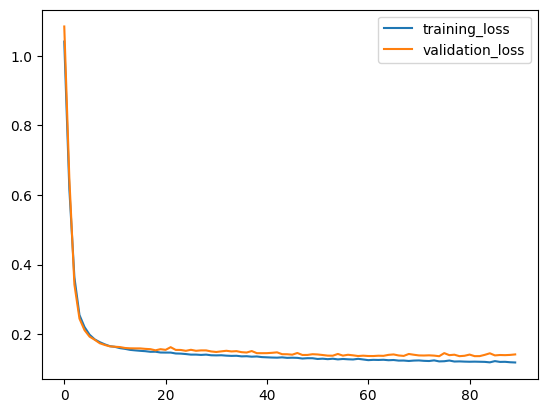

In [ ]:
plt.plot(history.history['loss'], label="training_loss")
plt.plot(history.history['val_loss'], label="validation_loss")
plt.legend()
plt.show()